---
date: "2026-07-20"
date-modified: last-modified
format:
  html:
    toc: true
---


# Student's t-Distribution

## 1\. Definition and Construction (Gosset, 1908)

The **Student's t-distribution** was introduced by William Sealy Gosset in 1908 while working as a chemist for the Guinness Brewery in Dublin. Publishing under the pseudonym *"Student"* to protect company trade secrets, Gosset derived this distribution to address the challenge of estimating the population mean of a normal distribution when the sample size is small and the true population variance $\sigma^2$ is unknown and must be estimated from the data.

::: {#def-student-t}
## Student's t-Distribution
Let $Z \sim \mathcal{N}(0, 1)$ be a [standard Normal random variable](normal-distribution.ipynb), and let $V \sim \chi^2(n)$ be a [Chi-Square random variable](chi-square-distribution.ipynb) with $n$ degrees of freedom, such that $Z$ and $V$ are [independent](independence-of-rvs.ipynb).

Define the ratio:

$$
T = \frac{Z}{\sqrt{V / n}}
$$

Then $T$ follows a **Student's t-distribution with $n$ degrees of freedom**, denoted:

$$
T \sim t_n
$$
:::

::: {.callout-note}
## Intuition: Uncertainty from Sample Variance
If the true variance $\sigma^2$ were known, standardizing the sample mean $\bar{X}$ would yield $Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0, 1)$. When $\sigma$ is replaced by the sample standard deviation $S$, the denominator introduces an additional random variable $V/n = S^2/\sigma^2$. Because $S$ fluctuates around $\sigma$, dividing by $\sqrt{V/n}$ injects extra variability, spreading probability mass from the center into the tails of the distribution.
:::

## 2\. Probability Density Function

The exact probability density function (PDF) of $T \sim t_n$ can be derived from the joint density of the independent numerator and denominator components.

::: {#thm-student-t-pdf}
## Probability Density Function of Student's t
If $T \sim t_n$, its probability density function is given by:

$$
f_T(t) = \frac{\Gamma\left(\frac{n+1}{2}\right)}{\sqrt{n\pi} \, \Gamma\left(\frac{n}{2}\right)} \left(1 + \frac{t^2}{n}\right)^{-\frac{n+1}{2}}, \quad -\infty < t < \infty
$$

where $\Gamma(\cdot)$ denotes the [Gamma function](gamma-function-and-distribution.ipynb).
:::

::: {.callout-tip collapse="true"}
## Proof of the Student's t Probability Density Function
Let $Z \sim \mathcal{N}(0, 1)$ and $V \sim \chi^2(n)$ be independent. Their joint density $f_{Z,V}(z, v)$ is the product of their marginal densities:

$$
f_{Z,V}(z, v) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2} \cdot \frac{(1/2)^{n/2}}{\Gamma(n/2)} v^{\frac{n}{2}-1} e^{-v/2}, \quad -\infty < z < \infty, \; v > 0
$$

We introduce a bivariate change of variables $(Z, V) \to (T, U)$:

$$
\begin{aligned}
T &= \frac{Z}{\sqrt{V / n}} \\
U &= V
\end{aligned}
$$

Inverting these equations expresses $(z, v)$ in terms of $(t, u)$:

$$
\begin{aligned}
z &= t \sqrt{\frac{u}{n}} \\
v &= u
\end{aligned}
$$

The Jacobian determinant of this transformation is given by:

$$
J = \det \begin{pmatrix} \frac{\partial z}{\partial t} & \frac{\partial z}{\partial u} \\ \frac{\partial v}{\partial t} & \frac{\partial v}{\partial u} \end{pmatrix} = \det \begin{pmatrix} \sqrt{\frac{u}{n}} & \frac{t}{2\sqrt{n u}} \\ 0 & 1 \end{pmatrix} = \sqrt{\frac{u}{n}}
$$

By the change of variables theorem for joint continuous distributions, the joint density $f_{T,U}(t, u)$ for $u > 0$ is:

$$
\begin{aligned}
f_{T,U}(t, u) &= f_{Z,V}\left(t\sqrt{\frac{u}{n}}, \, u\right) \cdot |J| \\
&= \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{t^2 u}{2n}\right) \frac{(1/2)^{n/2}}{\Gamma(n/2)} u^{\frac{n}{2}-1} e^{-u/2} \cdot \sqrt{\frac{u}{n}} \\
&= \frac{(1/2)^{\frac{n+1}{2}}}{\sqrt{n\pi} \, \Gamma(n/2)} u^{\frac{n+1}{2}-1} \exp\left( -\frac{u}{2} \left(1 + \frac{t^2}{n}\right) \right)
\end{aligned}
$$

To find the marginal density $f_T(t)$, we integrate out the auxiliary variable $u$ over $(0, \infty)$:

$$
f_T(t) = \frac{(1/2)^{\frac{n+1}{2}}}{\sqrt{n\pi} \, \Gamma(n/2)} \int_0^\infty u^{\frac{n+1}{2}-1} \exp\left( -\frac{u}{2} \left(1 + \frac{t^2}{n}\right) \right) du
$$

Recall that the Gamma function identity states that for constants $\alpha > 0$ and $\beta > 0$:

$$
\int_0^\infty u^{\alpha-1} e^{-\beta u} du = \frac{\Gamma(\alpha)}{\beta^\alpha}
$$

Setting $\alpha = \frac{n+1}{2}$ and $\beta = \frac{1}{2}\left(1 + \frac{t^2}{n}\right)$, the integral evaluates to:

$$
\int_0^\infty u^{\frac{n+1}{2}-1} \exp\left( -\frac{u}{2} \left(1 + \frac{t^2}{n}\right) \right) du = \frac{\Gamma\left(\frac{n+1}{2}\right)}{\left[ \frac{1}{2}\left(1 + \frac{t^2}{n}\right) \right]^{\frac{n+1}{2}}} = \frac{\Gamma\left(\frac{n+1}{2}\right)}{(1/2)^{\frac{n+1}{2}} \left(1 + \frac{t^2}{n}\right)^{\frac{n+1}{2}}}
$$

Substituting this result back into our expression for $f_T(t)$:

$$
\begin{aligned}
f_T(t) &= \frac{(1/2)^{\frac{n+1}{2}}}{\sqrt{n\pi} \, \Gamma(n/2)} \cdot \frac{\Gamma\left(\frac{n+1}{2}\right)}{(1/2)^{\frac{n+1}{2}} \left(1 + \frac{t^2}{n}\right)^{\frac{n+1}{2}}} \\
&= \frac{\Gamma\left(\frac{n+1}{2}\right)}{\sqrt{n\pi} \, \Gamma\left(\frac{n}{2}\right)} \left(1 + \frac{t^2}{n}\right)^{-\frac{n+1}{2}}
\end{aligned}
$$

$\blacksquare$
:::

## 3\. Fundamental Properties

The Student's t-distribution possesses five foundational mathematical and statistical properties:

::: {#thm-student-t-properties}
## Properties of the t-Distribution
Let $T \sim t_n$. Then:

1. **Symmetry:** The distribution is perfectly symmetric about zero: $-T \sim t_n$.
2. **Cauchy Special Case ($n = 1$):** When $n = 1$, $T \sim t_1$ is identical to the standard [Cauchy Distribution](Cauchy-distribution.ipynb).
3. **Zero Mean ($n \ge 2$):** For $n = 2$ (and generally for $n > 1$), $E[T] = 0$ by symmetry. For $n = 1$, the mean does not exist.
4. **Heavier Tails than Normal:** The density decays polynomially rather than exponentially, exhibiting thicker tails than $\mathcal{N}(0, 1)$.
5. **Asymptotic Normality ($n \to \infty$):** As $n$ becomes large, $t_n$ converges in distribution to the standard Normal distribution $\mathcal{N}(0, 1)$.
:::

::: {.callout-tip collapse="true"}
## Proof of Property (1): Symmetry
Observe the explicit form of the density function:

$$
f_T(-t) = \frac{\Gamma\left(\frac{n+1}{2}\right)}{\sqrt{n\pi} \, \Gamma\left(\frac{n}{2}\right)} \left(1 + \frac{(-t)^2}{n}\right)^{-\frac{n+1}{2}} = f_T(t)
$$

Because $f_T(t)$ is an even function of $t$, the distribution is symmetric about $0$, proving that $-T \sim t_n$. $\blacksquare$
:::

::: {.callout-tip collapse="true"}
## Proof of Property (2): Reduction to Cauchy Distribution for $n=1$
Substitute $n = 1$ directly into the density formula:

$$
f_T(t) = \frac{\Gamma\left(\frac{1+1}{2}\right)}{\sqrt{1 \cdot \pi} \, \Gamma\left(\frac{1}{2}\right)} \left(1 + \frac{t^2}{1}\right)^{-\frac{1+1}{2}} = \frac{\Gamma(1)}{\sqrt{\pi} \, \Gamma(1/2)} (1 + t^2)^{-1}
$$

Recall that $\Gamma(1) = 1$ and $\Gamma(1/2) = \sqrt{\pi}$. Therefore:

$$
f_T(t) = \frac{1}{\sqrt{\pi} \cdot \sqrt{\pi}} \frac{1}{1 + t^2} = \frac{1}{\pi(1 + t^2)}
$$

This is precisely the probability density function of the standard [Cauchy Distribution](Cauchy-distribution.ipynb). $\blacksquare$
:::

::: {.callout-tip collapse="true"}
## Proof of Property (3): Expectation $E[T] = 0$ for $n \ge 2$
By definition of expected value:

$$
E[T] = \int_{-\infty}^{\infty} t \, f_T(t) dt = \frac{\Gamma\left(\frac{n+1}{2}\right)}{\sqrt{n\pi} \, \Gamma\left(\frac{n}{2}\right)} \int_{-\infty}^{\infty} t \left(1 + \frac{t^2}{n}\right)^{-\frac{n+1}{2}} dt
$$

The integrand $g(t) = t \left(1 + \frac{t^2}{n}\right)^{-\frac{n+1}{2}}$ is an odd function since $g(-t) = -g(t)$. 

For the integral of an odd function over $(-\infty, \infty)$ to equal zero, it must be absolutely convergent ($\int_0^\infty |t| f_T(t) dt < \infty$). Examining the behavior of the integrand as $t \to \infty$:

$$
t \left(1 + \frac{t^2}{n}\right)^{-\frac{n+1}{2}} = O\left( t \cdot (t^2)^{-\frac{n+1}{2}} \right) = O\left( t \cdot t^{-n-1} \right) = O(t^{-n})
$$

The improper integral $\int_1^\infty t^{-n} dt$ converges if and only if $n > 1$. Therefore:

* When $n = 1$ (Cauchy), $\int_1^\infty t^{-1} dt = \ln t \big|_1^\infty = \infty$, so the expected value **does not exist**.
* When $n \ge 2$, the integral converges absolutely, and by symmetry of the odd integrand, $E[T] = 0$. $\blacksquare$
:::

::: {.callout-tip collapse="true"}
## Proof of Property (5): Asymptotic Normality as $n \to \infty$
We prove that $T \sim t_n \xrightarrow{d} \mathcal{N}(0, 1)$ as $n \to \infty$ using both probabilistic convergence (Slutsky's Theorem) and analytic limits of the PDF.

**Method 1: Using Slutsky's Theorem**
By construction, $T = \frac{Z}{\sqrt{V_n / n}}$, where $Z \sim \mathcal{N}(0, 1)$ and $V_n = \sum_{i=1}^n Z_i^2 \sim \chi^2(n)$.
By the [Weak Law of Large Numbers](law-of-large-numbers-and-central-limit-theorem.ipynb), the sample average of squared Normal variables converges in probability to their expectation:

$$
\frac{V_n}{n} = \frac{1}{n} \sum_{i=1}^n Z_i^2 \xrightarrow{P} E[Z_1^2] = 1, \quad \text{as } n \to \infty
$$

By the Continuous Mapping Theorem, $\sqrt{V_n / n} \xrightarrow{P} 1$.
Applying Slutsky's Theorem to the ratio of $Z \sim \mathcal{N}(0, 1)$ and $\sqrt{V_n / n} \xrightarrow{P} 1$:

$$
T = \frac{Z}{\sqrt{V_n / n}} \xrightarrow{d} \frac{Z}{1} = Z \sim \mathcal{N}(0, 1)
$$

**Method 2: Direct Limit of the PDF**
Examine the variable part of $f_T(t)$ as $n \to \infty$:

$$
\lim_{n \to \infty} \left(1 + \frac{t^2}{n}\right)^{-\frac{n+1}{2}} = \lim_{n \to \infty} \left[\left(1 + \frac{t^2}{n}\right)^n\right]^{-\frac{1}{2}} \cdot \lim_{n \to \infty} \left(1 + \frac{t^2}{n}\right)^{-\frac{1}{2}} = (e^{t^2})^{-1/2} \cdot 1 = e^{-t^2/2}
$$

Using Stirling's approximation $\Gamma(x + 1) \sim \sqrt{2\pi x} (x/e)^x$ for the normalizing constant yields:

$$
\lim_{n \to \infty} \frac{\Gamma\left(\frac{n+1}{2}\right)}{\sqrt{n\pi} \, \Gamma\left(\frac{n}{2}\right)} = \frac{1}{\sqrt{2\pi}}
$$

Combining both limits proves that $\lim_{n \to \infty} f_T(t) = \frac{1}{\sqrt{2\pi}} e^{-t^2/2}$, the standard Normal PDF. $\blacksquare$
:::

## 4\. Visualizing the Student's t-Distribution

The visualization below illustrates how the heavy tails of the Student's t-distribution progressively shrink toward the standard Normal distribution as degrees of freedom $n$ increase. When $n=1$ (Cauchy), extreme values are frequent; by $n=30$, the curve is virtually indistinguishable from $\mathcal{N}(0, 1)$.

In [1]:
import warnings
warnings.filterwarnings('ignore')

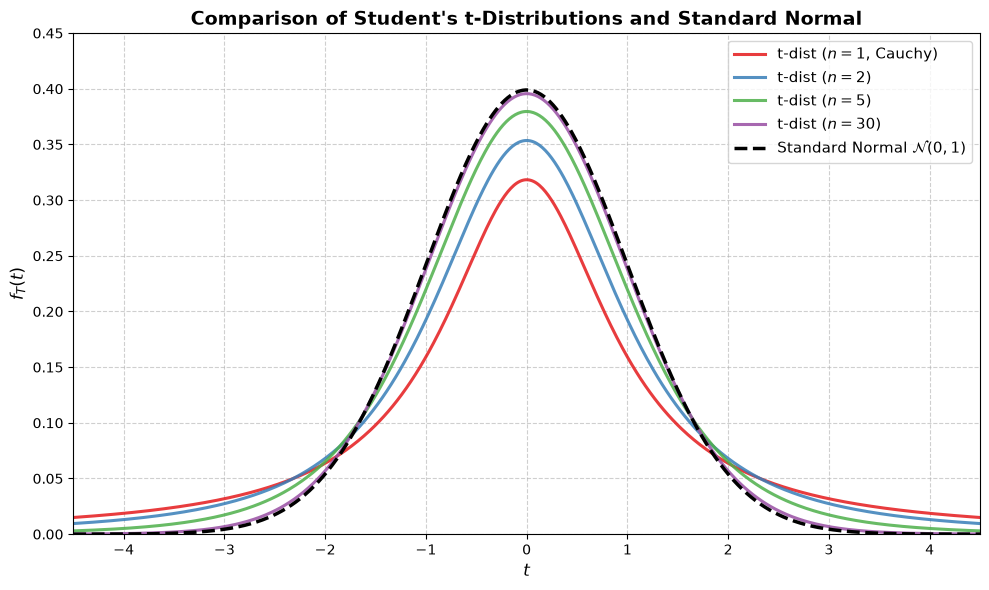

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Set up grid
x = np.linspace(-4.5, 4.5, 600)
df_values = [1, 2, 5, 30]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

plt.figure(figsize=(10, 6))

# Plot t-distributions
for df, color in zip(df_values, colors):
    pdf = t.pdf(x, df)
    label = f't-dist ($n = {df}$)' if df != 1 else 't-dist ($n = 1$, Cauchy)'
    plt.plot(x, pdf, label=label, color=color, lw=2.2, alpha=0.85)

# Plot standard Normal for comparison
plt.plot(x, norm.pdf(x), label='Standard Normal $\mathcal{N}(0, 1)$', color='black', lw=2.5, linestyle='--')

plt.title("Comparison of Student's t-Distributions and Standard Normal", fontsize=14, fontweight='bold')
plt.xlabel('$t$', fontsize=12)
plt.ylabel('$f_T(t)$', fontsize=12)
plt.ylim(0, 0.45)
plt.xlim(-4.5, 4.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()